## Customer Churn Analysis for the Telco 

In [1]:
# imports and loads

import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs('./results', exist_ok=True)


unclean_df = pd.read_csv('./data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = unclean_df.dropna().drop_duplicates()

# UTILITIES
df['has_churned'] =  df['Churn'] == 'Yes'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
# df.to_excel('./excel.xlsx')


# Add the column that classifies the customers by tenure cohort
bins = [0, 3, 6, 9, 12, 24, 50, float('inf')]
labels = ['0-3', '4-6', '7-9', '10-12', '13-24', '25-50', '50+']

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)


### General Metrics

In [ ]:
# overall mertics
total_customers = df['customerID'].count()
churn_true = (df['Churn'] == 'Yes').sum()
total_churn_rate = round((churn_true / total_customers) * 100, 2)
total_retention_rate = (100 - total_churn_rate).round(2)

print(f"Total Customers: {total_customers}")
print(f"Churned: {churn_true}")
print(f"Churn Rate: {total_churn_rate}%")
print(f"Retention Rate: {total_retention_rate}%")

Total Customers: 7043
Churned: 1869
Churn Rate: 26.54%
Retention Rate: 73.46%


### Churn by Segments 
#### Churn by Partnership
The chart below clearly shows that the non-members have churned more than the members.

This might be caused by: 
- Short term customers who subscribe just for a short period of time with no intention to stay for long time.
- Bad customer retention techniques by the business.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_60980\2804651779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate_partners, x='Partner', y='has_churned', palette=['#2ecc71', '#e74c3c'])


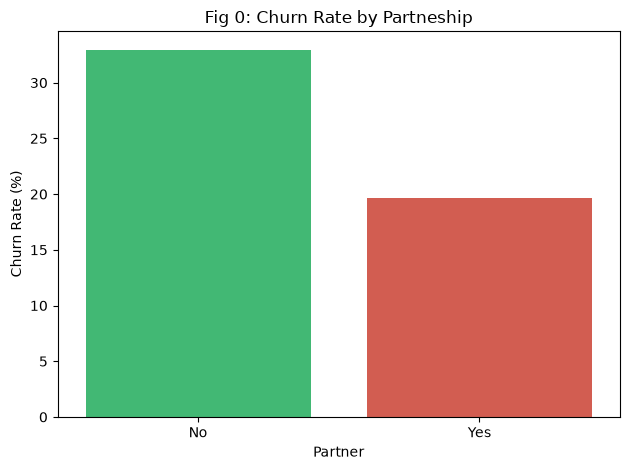

In [19]:
churn_rate_partners = ((df.groupby('Partner')['has_churned'].mean() * 100).round(2)).reset_index()
plt.figure()
sns.barplot(data=churn_rate_partners, x='Partner', y='has_churned', palette=['#2ecc71', '#e74c3c'])
plt.xlabel('Partner')
plt.ylabel('Churn Rate (%)')
plt.title('Fig 0: Churn Rate by Partneship')
plt.tight_layout()
plt.savefig('./results/00_churn_rate_by_partnership.png', dpi=300)

#### Churn by Contract 

The Chart below shwows that long term contractors don't churn more often as month-to-month.

The Hypothesis around that would be that month-to month people are just testing to see of they will get by the system and some of them decide to leave.

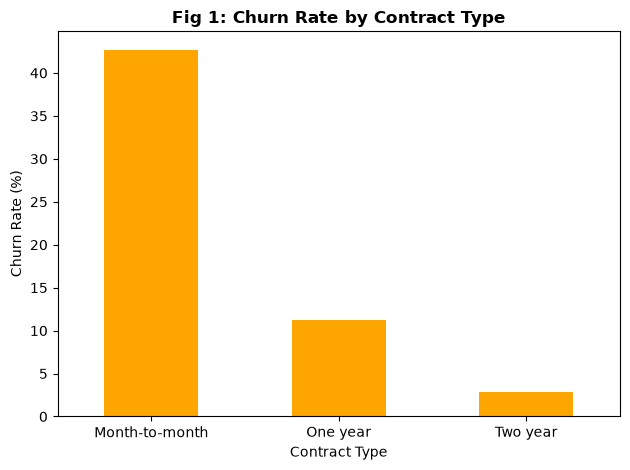

In [4]:
plt.figure()
churn_by_contract = (df.groupby('Contract')['has_churned'].mean() * 100).round(2)
churn_by_contract.plot(kind='bar', color='orange')
plt.title('Fig 1: Churn Rate by Contract Type', fontsize=12, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./results/01_churn_by_contract.png', dpi=300)
plt.show()

#### Churn By Tenure
##### Churn By Tenure Cohort
The 2 Charts Below clearly shows that new customers tend to churn more than regular customers.

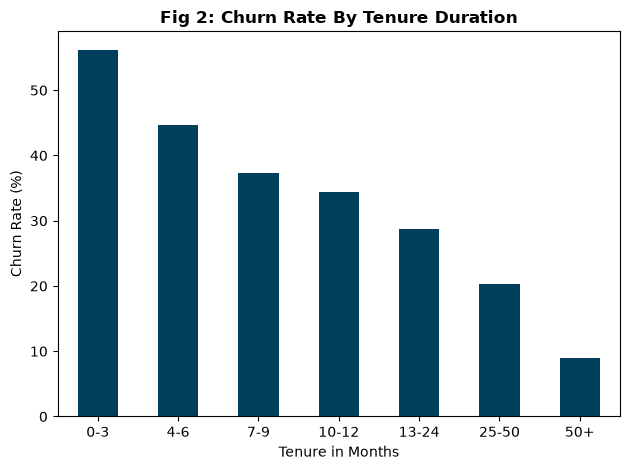

In [5]:
# churn by tenure 
plt.figure()

churn_by_tenure_group = (df.groupby('tenure_group')['has_churned'].mean() * 100).round(2)
churn_by_tenure_group.plot(kind='bar', color="#003f5c")
plt.title("Fig 2: Churn Rate By Tenure Duration", fontsize=12, fontweight="bold")
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure in Months')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./results/02_churn_by_tenure.png', dpi=300)
plt.show()


##### Comparison of Churn and Retain Rate According to Tenure Duration 

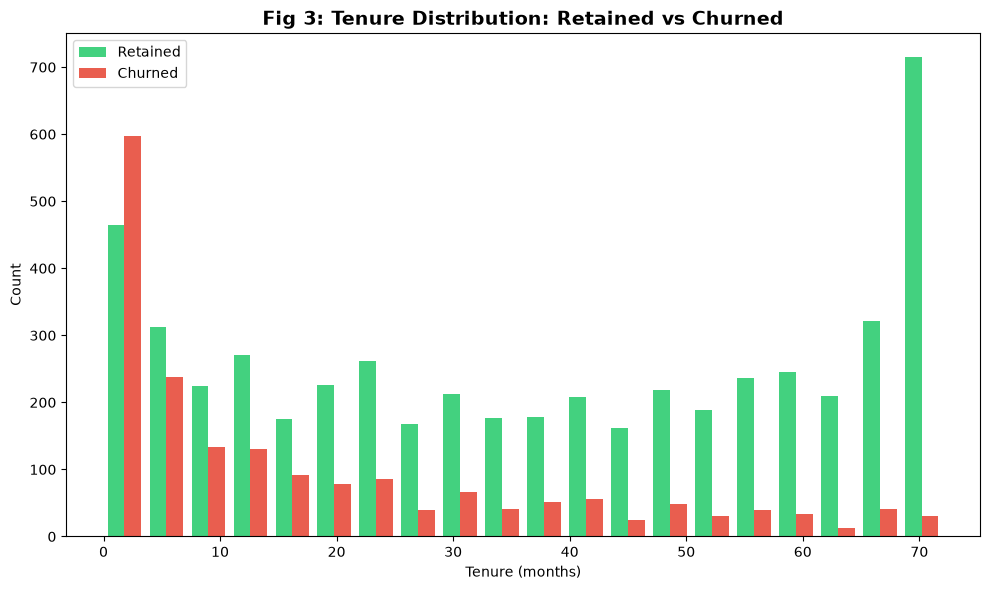

In [6]:
plt.figure(figsize=(10, 6))
churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']
plt.hist([retained, churned], bins=20, label=['Retained', 'Churned'], color=['#2ecc71', '#e74c3c'], alpha=0.9)
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.title('Fig 3: Tenure Distribution: Retained vs Churned', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('./results/03_tenure_distribution.png', dpi=300)
plt.show()

#### Montly Charges Analysis: Churned vs Retailed
The Figure below is not conlusive because the boxes overlap and do not show a distinct difference, however, there is a gap between the median lines, this is likely because over 40% of the fiber optic users, which is the most expensive, churned.

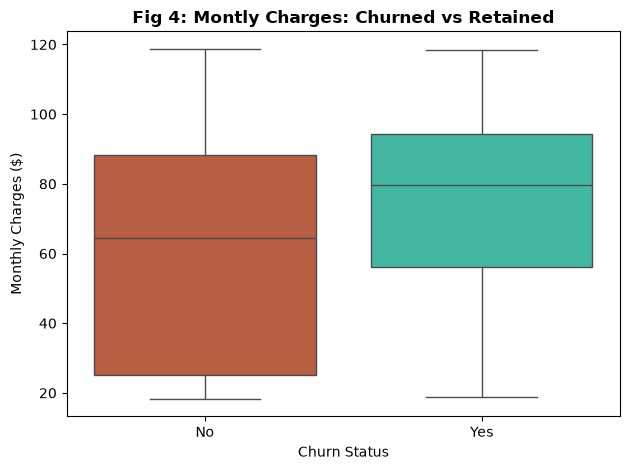

In [7]:
# Montly Charges: Churned vs Retailed

plt.figure()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',hue='Churn', palette=["#cc532ede", "#2eccaf"], legend=False)
plt.title('Fig 4: Montly Charges: Churned vs Retained', fontsize=12, fontweight='bold')
plt.ylabel('Monthly Charges ($)')
plt.xlabel('Churn Status')
plt.tight_layout()
plt.savefig('./results/04_charges_comparison.png', dpi=300)


### Churn rate by internet Service

The churn rate of the fiber optic users is clearly ahead of others. This is probably because it is the most expensive.

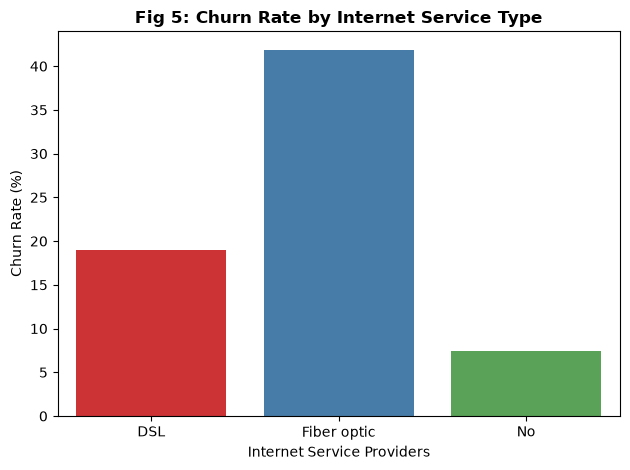

In [8]:
plt.figure()
churn_by_internet = (df.groupby('InternetService')['has_churned'].mean() * 100).round(2)
churn_by_internet_df = churn_by_internet.reset_index()
churn_by_internet_df.columns = ['InternetService', 'ChurnRate']

sns.barplot(data=churn_by_internet_df, x='InternetService', y='ChurnRate', palette="Set1", hue="InternetService")
plt.title("Fig 5: Churn Rate by Internet Service Type", fontsize=12, fontweight='bold')
plt.xlabel('Internet Service Providers')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('./results/05_churn_by_internet_service.png', dpi=300)
plt.show()


### Churn Rate By Phone Service

The Chart below shows that the phone service barely have an effect on customers' churn decision.

#

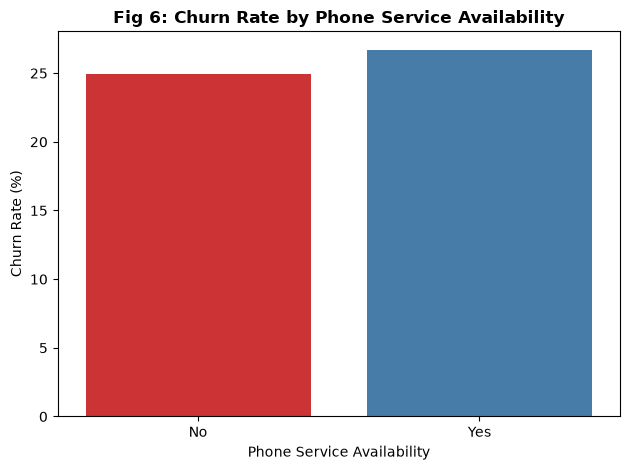

In [ ]:
# Churn by phone service

plt.Figure()
churn_rate_by_phone_service = (df.groupby('PhoneService')['has_churned'].mean() * 100).round(2)
churn_rate_by_phone_service_df = churn_rate_by_phone_service.reset_index()
sns.barplot(data=churn_rate_by_phone_service_df, x='PhoneService', y='has_churned', palette='Set1', hue='PhoneService')
plt.title('Fig 6: Churn Rate by Phone Service Availability', fontsize=12, fontweight='bold')
plt.xlabel('Phone Service Availability')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('./results/06_churn_by_phone_service_availability.png', dpi=300)
plt.show()


### Churn Rate by Citizen Status

The chart below shows that senior citizens tends to churn more than non-seniors.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_60980\1910213553.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_citizenship_status_df, x='SeniorCitizen', y='has_churned', palette='Set3')


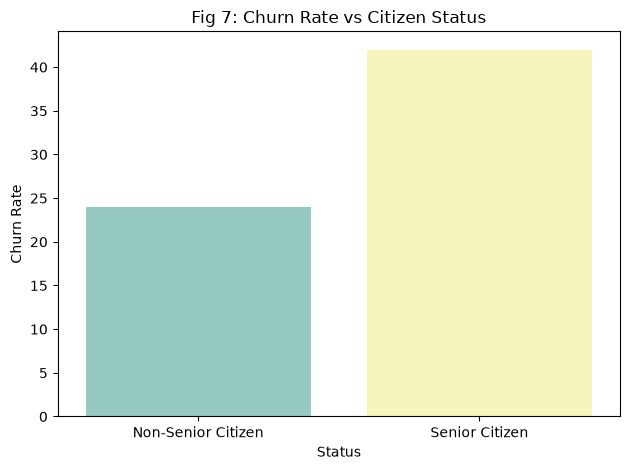

In [10]:
# Churn by Citisenship status
plt.figure()
churn_by_citizenship_status = (df.groupby('SeniorCitizen')['has_churned'].mean() * 100).round(0)
churn_by_citizenship_status_df = churn_by_citizenship_status.reset_index()

sns.barplot(data=churn_by_citizenship_status_df, x='SeniorCitizen', y='has_churned', palette='Set3')
plt.title('Fig 7: Churn Rate vs Citizen Status')
plt.xlabel('Status')
plt.xticks(ticks =[0, 1], labels=['Non-Senior Citizen', 'Senior Citizen'])
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('./results/07_churn_by_citizenship_status.png', dpi=300)


#### Internet Type vs Cost

Fiber Optic is the most expensive internet type.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_60980\2776514378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='InternetService', y='MonthlyCharges', palette='Set2')


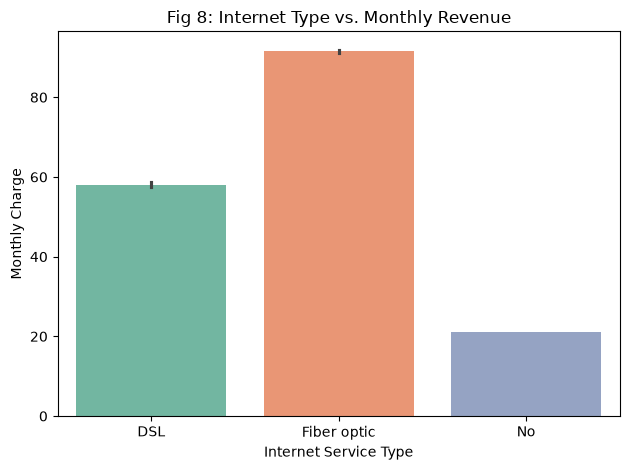

In [ ]:
# Are Fiber Optics More Expensive??
plt.figure()
sns.barplot(data=df, x='InternetService', y='MonthlyCharges', palette='Set2')
plt.title('Fig 8: Internet Type vs. Monthly Revenue')
plt.ylabel('Monthly Charge ($)')
plt.xlabel('Internet Service Type')
plt.tight_layout()
plt.savefig('./results/09_monthly_charges_by_internet_type.png', dpi=300)
plt.show()

### Fiber Optics vS. Contract Type

Fiber Optic users tend to use month-to-month subscription. 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_60980\3546460147.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_type_vs_fiber, x="Contract", y="has_fiber", palette='Set1')


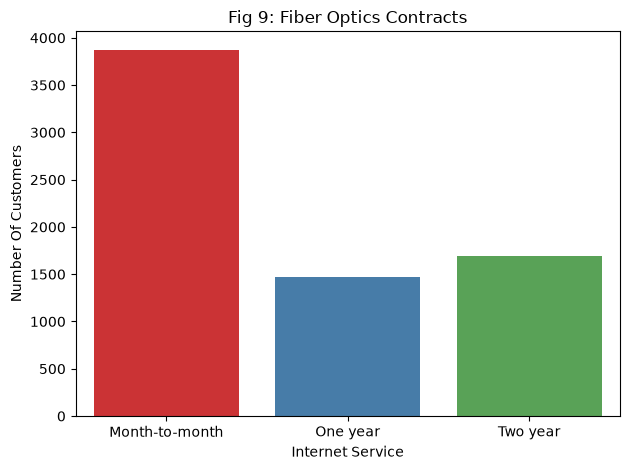

In [ ]:
# Fiber Optics vs contract type

plt.figure()

df['has_fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)
contract_type_vs_fiber = df.groupby('Contract')['has_fiber'].count().reset_index()
sns.barplot(data=contract_type_vs_fiber, x="Contract", y="has_fiber", palette='Set1')
plt.title('Fig 9: Fiber Optics Contracts')
plt.xlabel('Internet Service')
plt.ylabel('Number Of Customers')
plt.tight_layout()
plt.savefig('./results/10_fiber_optics_contracts.png', dpi=300)

### Support Level vs Citizen Status
Senior citizens do not receive enough tech support.

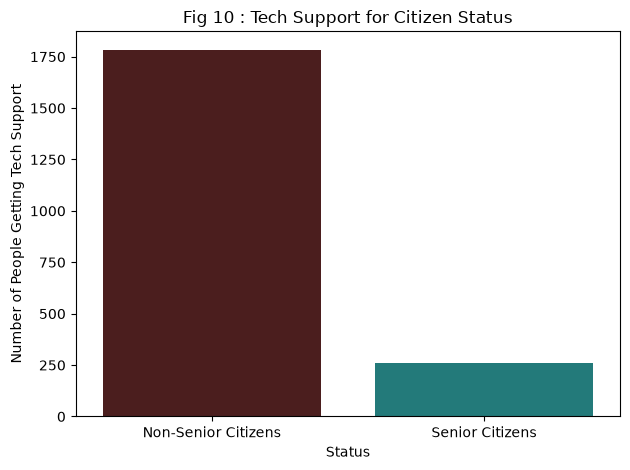

In [25]:
# support level vs citizen status
df_tech_support = df[df['TechSupport'] == 'Yes']

tech_support_citizen_status = df_tech_support.groupby('SeniorCitizen')['TechSupport'].count().reset_index()
plt.figure()
sns.barplot(data=tech_support_citizen_status, x="SeniorCitizen", y='TechSupport',hue="SeniorCitizen", legend=False, palette=["#531616", '#158888'])
plt.xticks(ticks=[0,1], labels=['Non-Senior Citizens', 'Senior Citizens'])
plt.title('Fig 10 : Tech Support for Citizen Status')
plt.xlabel('Status')
plt.ylabel('Number of People Getting Tech Support')
plt.tight_layout()
plt.savefig('./results/11_support_level_by status.png', dpi=300)
plt.show()

## Final Report

### Top Churn Risk Factors:
1. **Internet Service Type**: The three categories (Fiber, DSL and No), shows a big difference in Churn Rates with the People using the Fiber Service Churning More.
#### Possible Causes
- **High Amount of Charges:**:As Fig 8  shows, the monthly charges for the Fiber Optics is signiuficantly more than other 2 and the shape is almost similar to the charn vs Internet Service.
**Hypothesis:** The Customers are leacing because the charges of Fiber Optics are high.
- **Contract Type for Fiber Optics Type Customers**: As Fig 9 shows, the most of fiber optic subrcribers are on a month contracts and as in Fig 1: Over 40% of month-to-month people churned
**Hypothesis:** The Contract type of the Fiber optic subscribers is the cause of a big churn rate. 

2. **Tenure**: Fig 2 clearly shows that the churn rate is extremely tenure-dependent, where the churn rate in the first three months is 100%+ more than any other group, And the retain rate of 50+ tenure period is more than any other group.
**Hypothesis:** The long tenure customers are not likely to churn wnd the new customers are more likely to leave the company.
3. **Monthly Charges**: As Fig 4 shows, the median mothly charges for the churned is slightly more than the retained.
### High-Risk Segment:
- The high risk segment is tenure duration: there is a clear difference on churn rate between new customers and long term customers.
- The Senior Citizens churn rate is very big (over 40%).

### Recommendations:
- Create **good impression** of the company to the new customers so that they do not churn in their first 3 months of theis first subscription.
- **Looking at Fig 11**, The Senior Citizens are not given enough tech support, that is one of the reasons why we see a big difference between churn rates of Senior and non-senior citizens. The recommendation is to **make sure that all senior citizens are given adequate tech support.**
